In [1]:
import src.opt as opt
import os
import numpy as np
from sklearn.cluster import SpectralClustering
import cvxpy as cp
import mosek

import src.utils as utils

SAVE = True
PREFIX = './results/sem_neg'

# Check restuls dir exists and create
if not os.path.exists(PREFIX):
    os.makedirs(PREFIX)

## Load and plot data

Shape of: X: (122, 1214)  -  Y: (2, 1214)  -  data: (124, 1214)
(Min, Max) values of: X: (-7.201, 18.151)  - Y: (-1.731, 1.732)  -  data: (-7.201, 18.151)
Mean value of: X: 0.000  -  Y: -0.000  -  data: 0.000
Std value of: X: 1.000  -  Y: 1.000  -  data: 1.000
lamb0: 0.06301252173882214


<Figure size 900x600 with 0 Axes>

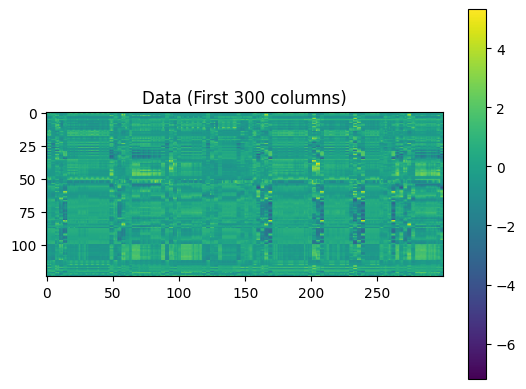

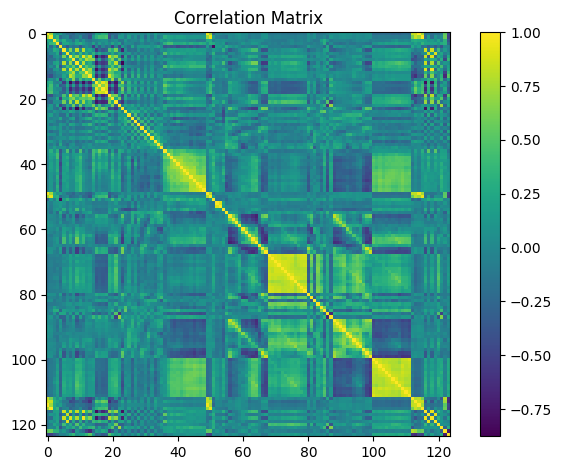

In [2]:
Data = utils.load_accoustic_data(all_data=True)
N, M = Data.shape

lamb0 = np.sqrt(np.log(N)/M)
print('lamb0:', lamb0)

## Undirected SEM

In [3]:
# Estimate A
lamb0 = np.sqrt(np.log(N)/M)

# Mults = np.array( [159.78, 264.05, 368.32, 472.59] ) / lamb0
Mults = np.array( [159.78, 300, 360, 472.59] ) / lamb0


A_undir_sem = []
for mult in Mults:
    lamb = mult*lamb0

    A_est = opt.sparse_id(Data, lamb, symmetric=True,  verbose=False)
    print(f'Lamb (mult): {lamb:.4f} ({mult})')
    A_undir_sem.append(A_est)
    


Lamb (mult): 159.7800 (2535.6864888262235)
Lamb (mult): 300.0000 (4760.958484465309)
Lamb (mult): 360.0000 (5713.150181358371)
Lamb (mult): 472.5900 (7499.9379005782)


In [4]:
# # LOAD DATA
# lamb0s = [159.78]
# A_undir_sem = []
# Mults = [1]*len(lamb0s)
# for lamb0 in lamb0s:
#     file_name = PREFIX + f'/sem_und_{lamb0}.npy'
#     A_undir_sem.append(np.load(file_name, allow_pickle=True))
# A_undir_sem = [np.load(file_name, allow_pickle=True)]


### Plot graph and adjacency

- Lambda: 159.7800  -  Edge density above threshold: 0.055  -  Output edges: 10
	Saved as: ./results/sem_neg/sem_und_159.78
- Lambda: 300.0000  -  Edge density above threshold: 0.041  -  Output edges: 9
	Saved as: ./results/sem_neg/sem_und_300.0
- Lambda: 360.0000  -  Edge density above threshold: 0.036  -  Output edges: 8
	Saved as: ./results/sem_neg/sem_und_360.0
- Lambda: 472.5900  -  Edge density above threshold: 0.030  -  Output edges: 6
	Saved as: ./results/sem_neg/sem_und_472.59


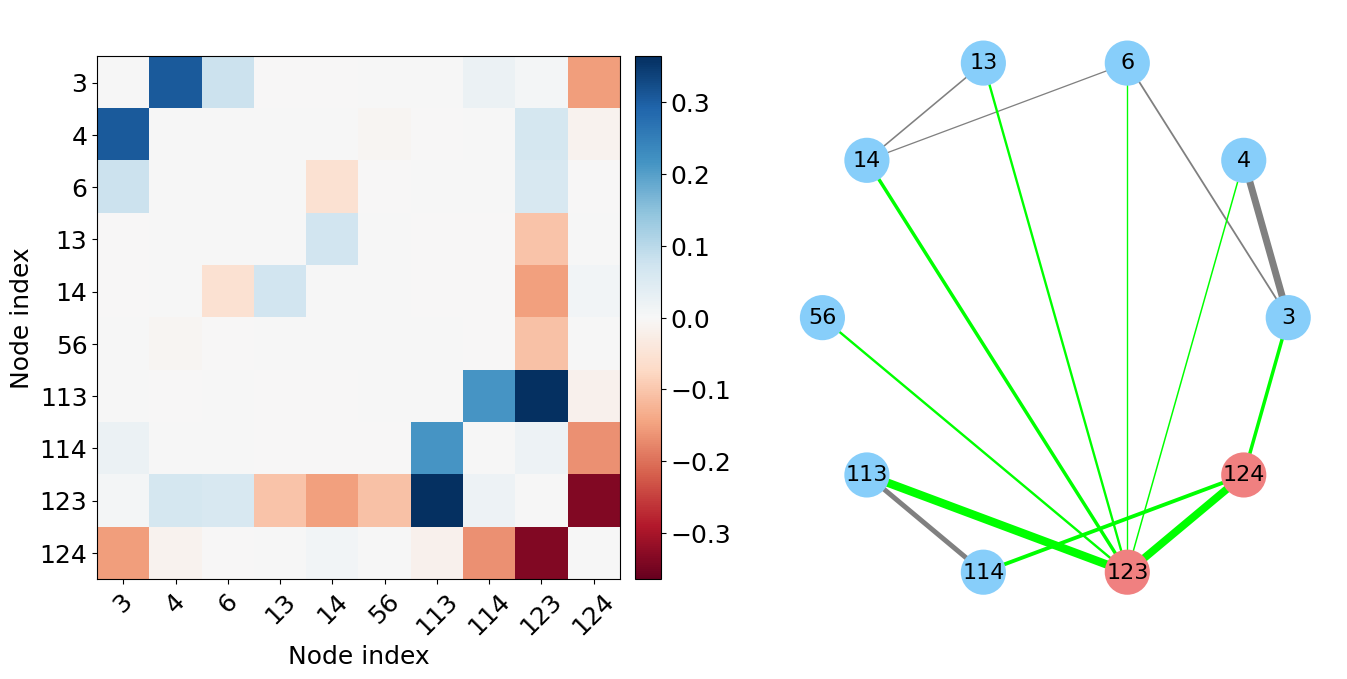

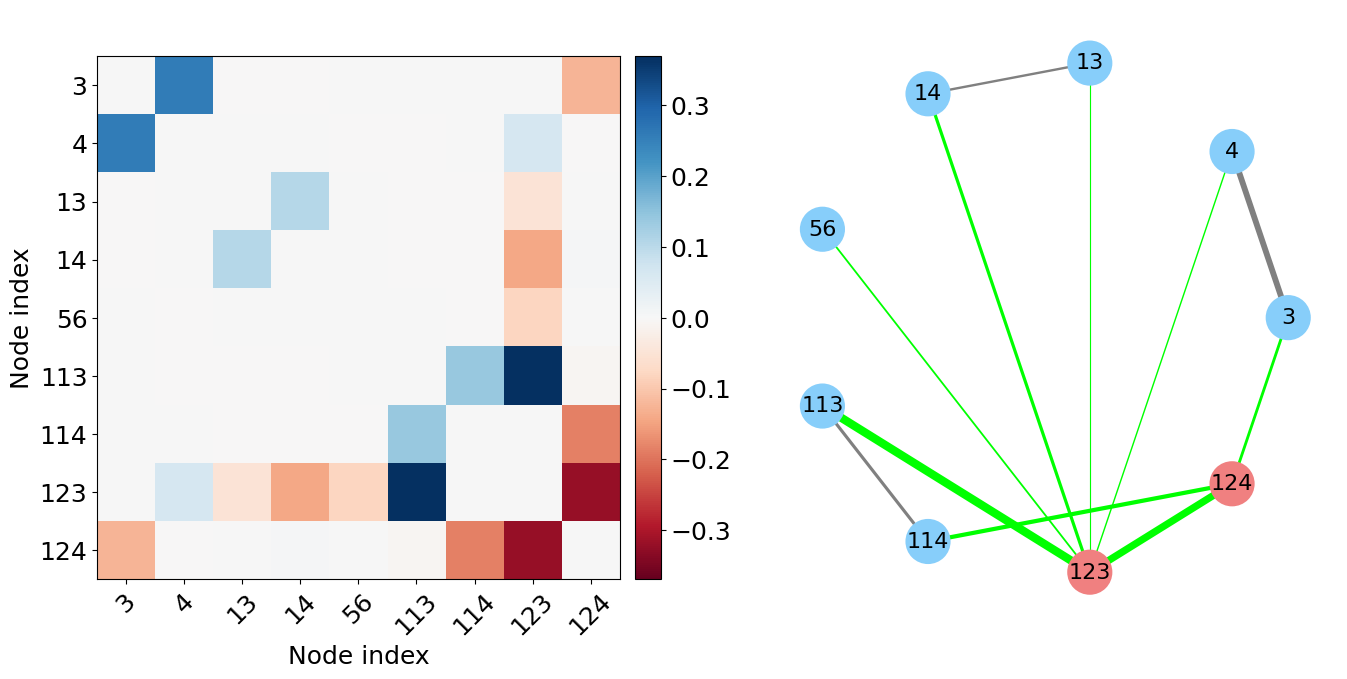

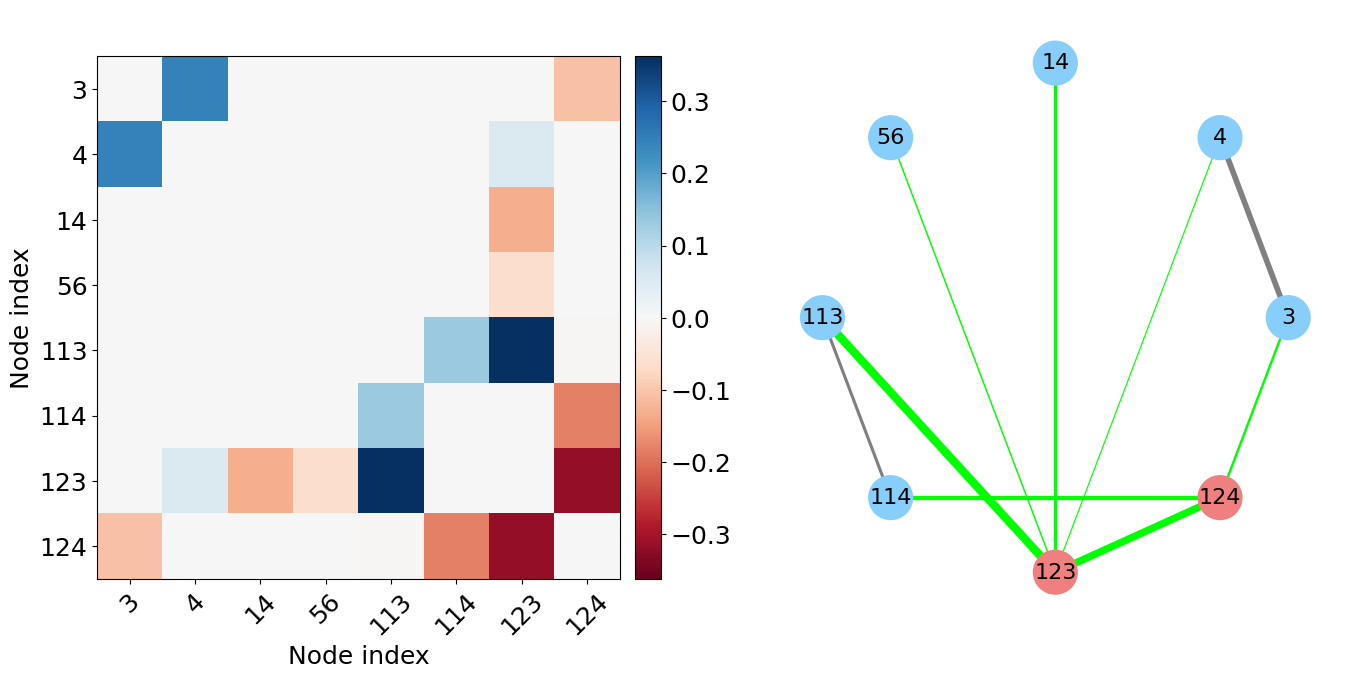

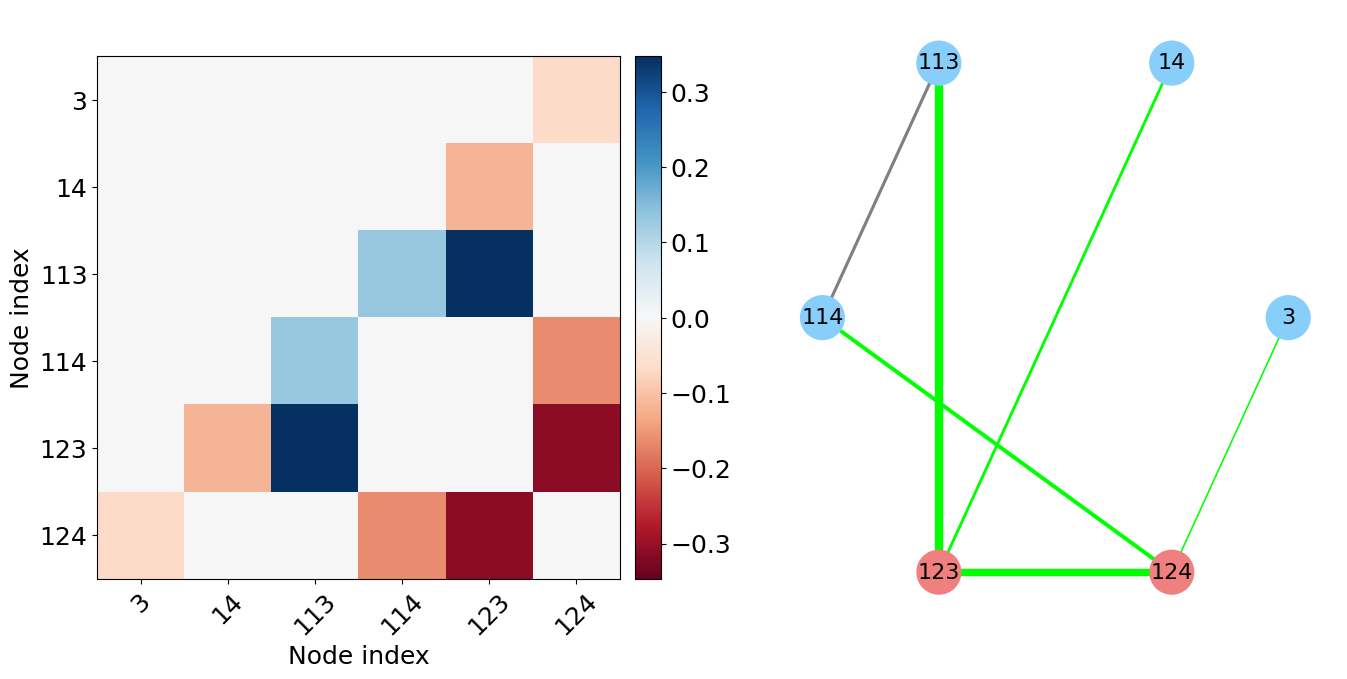

In [5]:
# Plot A
th = 0.05
for i, A_est in enumerate(A_undir_sem):
    mult = Mults[i] * lamb0
    file_name = f'{PREFIX}/sem_und_{mult}'
    # utils.save_plot_graph(A_est, th, mult, max_width=4, file_name=file_name, save=SAVE)
    utils.save_plot_subgraph(A_est, th, mult, save=SAVE, max_width=6, file_name=file_name)
    utils.sort_edges_by_weight(A_est, th, output_file=file_name, abs_val=True, save=SAVE)

### Plot for different thresholds

Plotting grid for Lambda idx 0: 159.7800
	Individual plots saved in: ./results/sem_neg/thresholds
Plotting grid for Lambda idx 3: 472.5900
	Individual plots saved in: ./results/sem_neg/thresholds


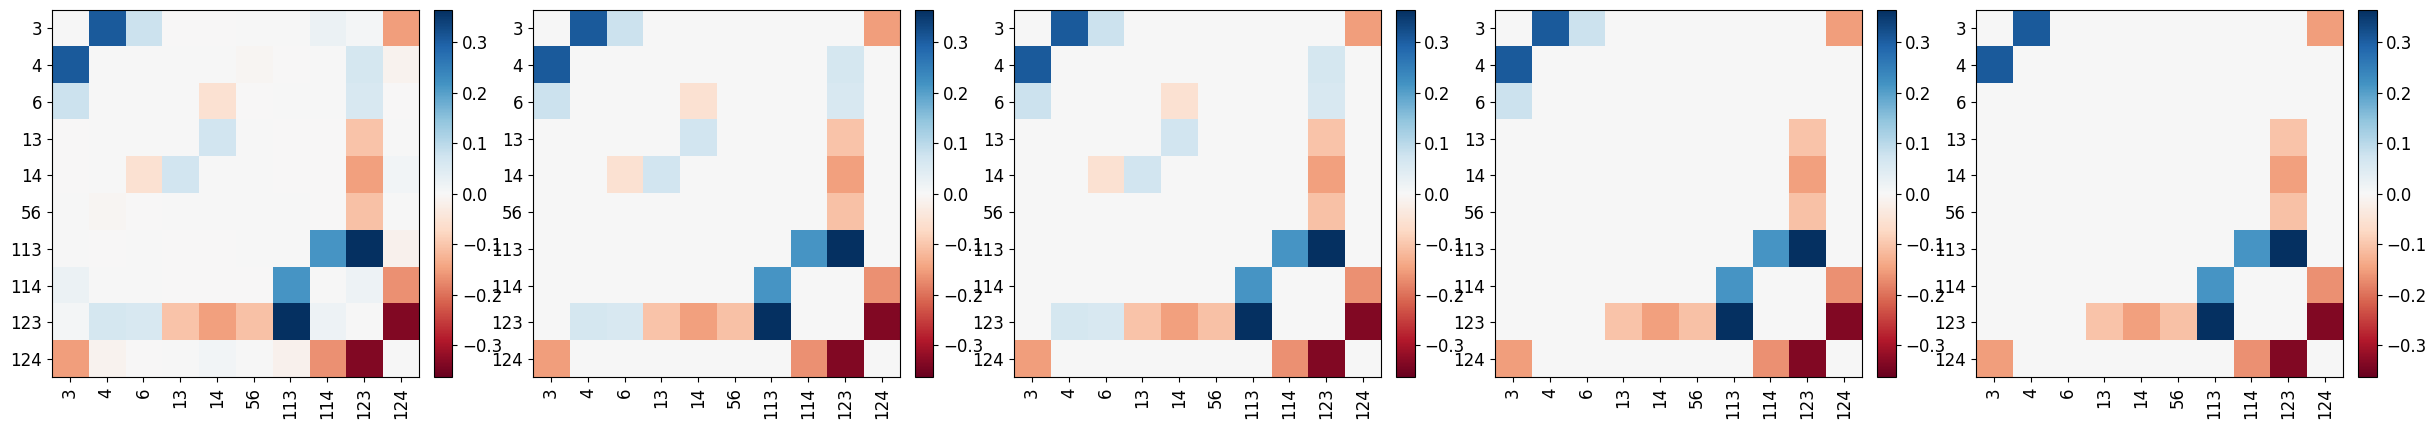

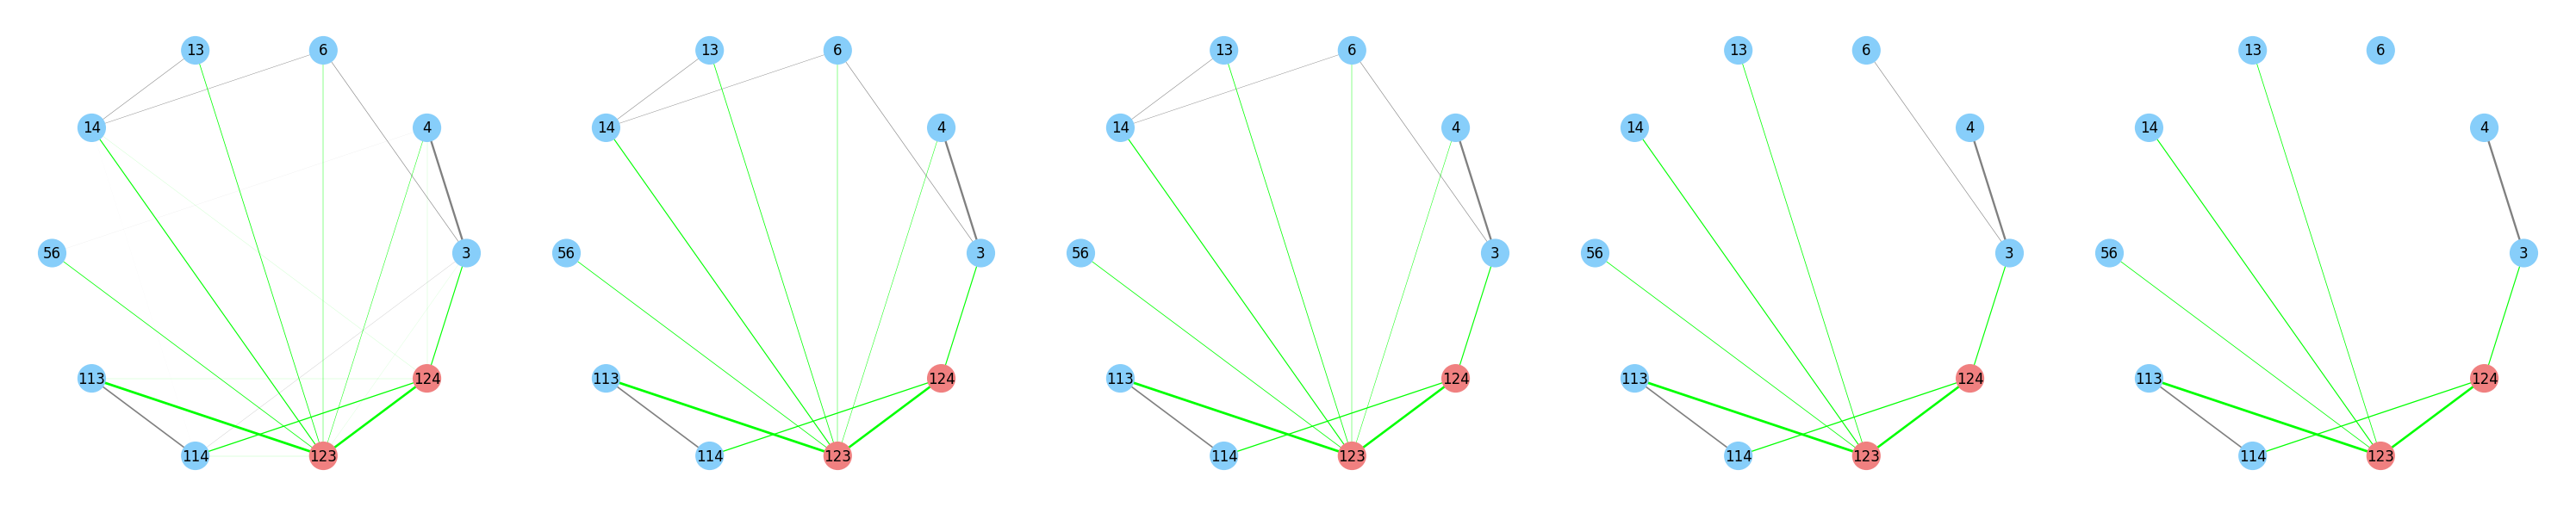

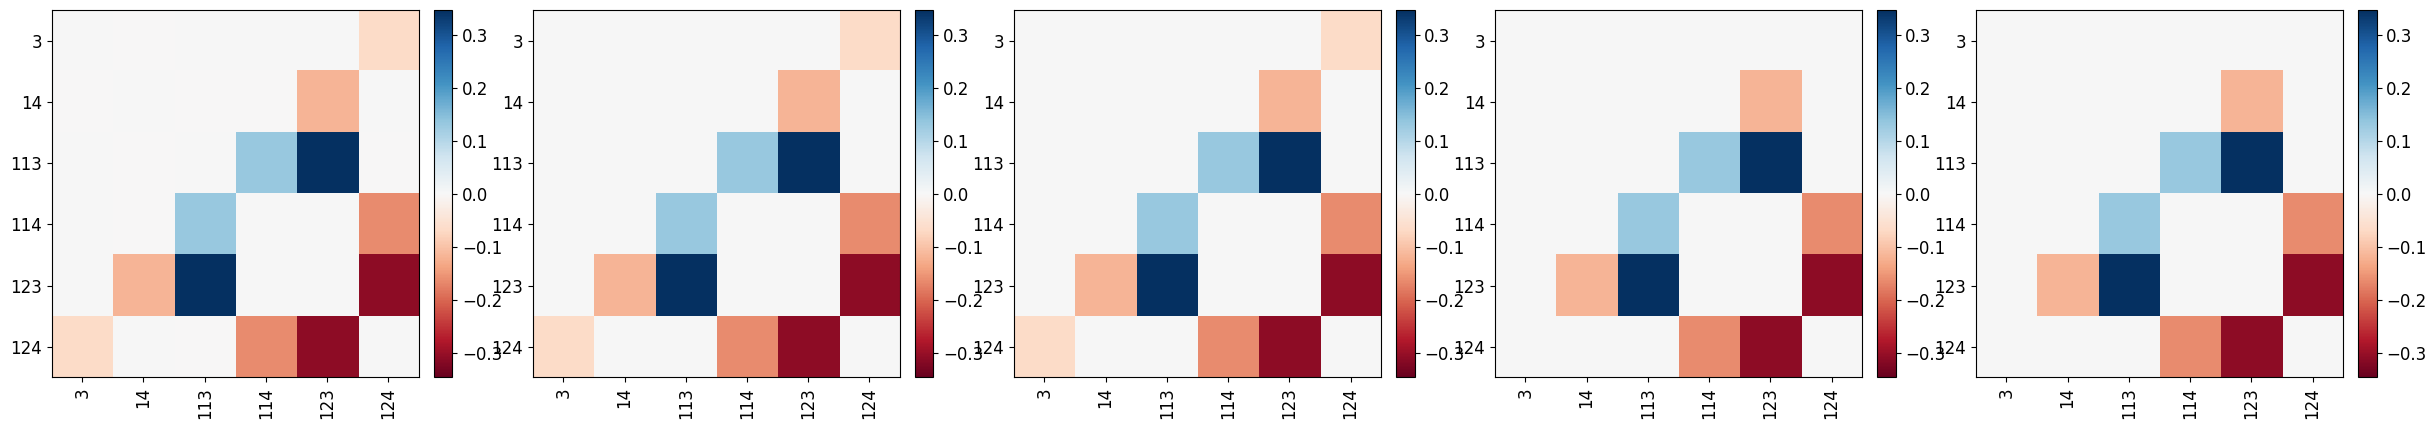

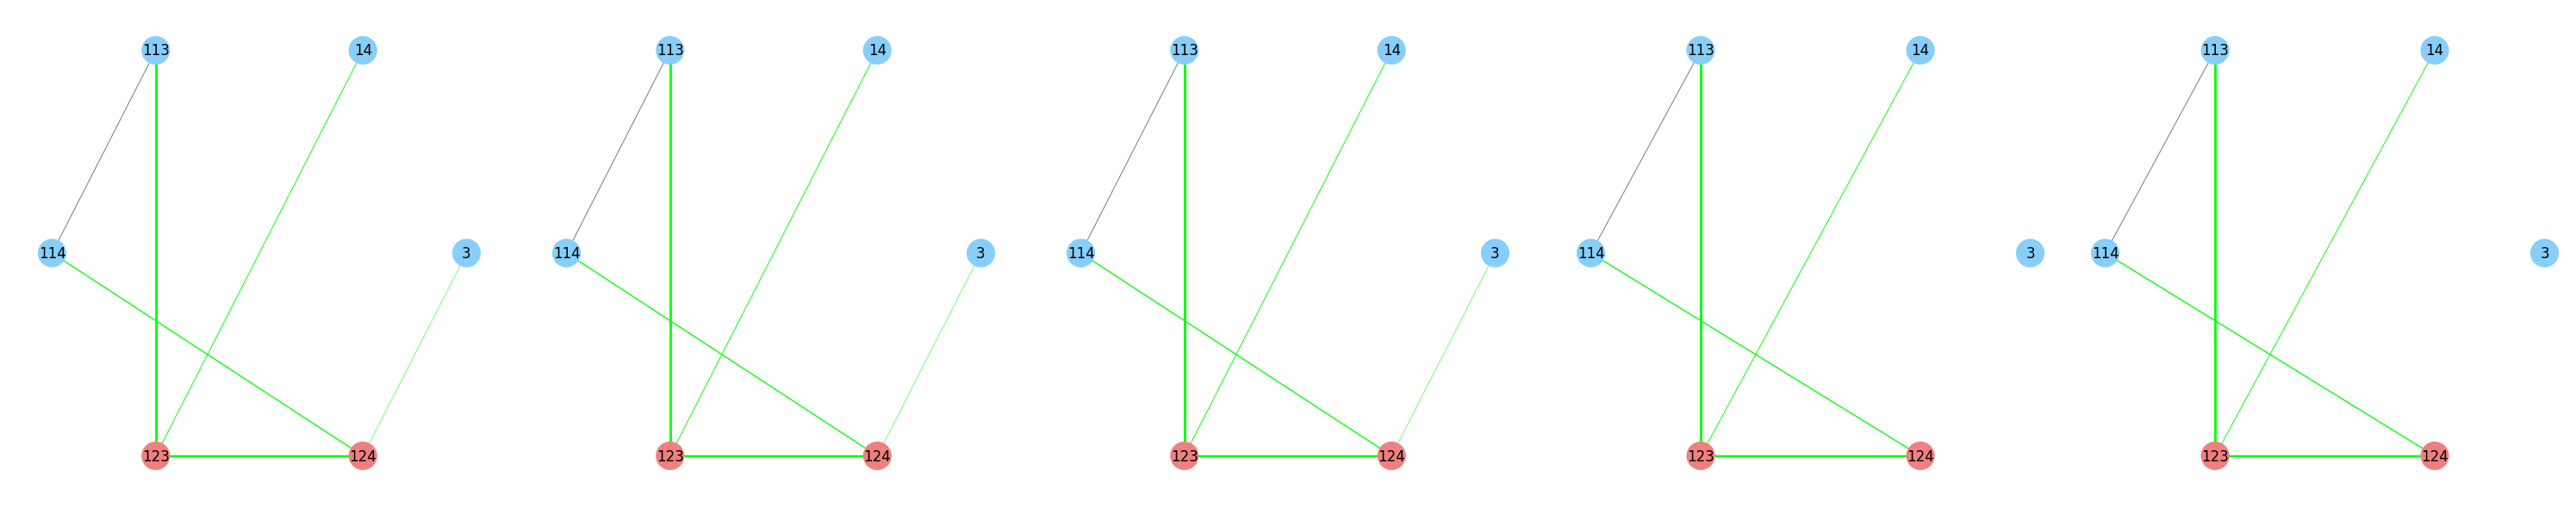

In [6]:
# Plot A - Grid for thresholds
fix_th = 0.05
thresholds = [0, 0.025, 0.05, 0.075, 0.1]

# skip_idx = [2,3]
skip_idx = [1,2]


# lambdas = Mults * lamb0

for i, A_est in enumerate(A_undir_sem):
    
    if i in skip_idx:
        continue
    
    lamb = Mults[i] * lamb0
    print(f'Plotting grid for Lambda idx {i}: {lamb:.4f}')
    
    utils.save_plot_subgraph_grid(A_est, thresholds, lamb, th_fixed_subgraph=fix_th, plot_graph=True,
                                  file_name=f'{PREFIX}/sem_und_grid_fix_{lamb}', save=SAVE)


## Without connection of outputs variables

In [7]:
PREFIX = './results/sem_neg_unc'

In [12]:

# Estimate A
lamb0 = np.sqrt(np.log(N)/M)

# Mults = np.array( [159.78, 280, 300, 320, 360, 472.59] ) / lamb0
Mults = np.array( [159.78, 300, 360, 472.59] ) / lamb0
A_undir_sem = []
for mult in Mults:
    lamb = mult*lamb0

    A_est = opt.sparse_id(Data, lamb, symmetric=True, zero_indices=[[-1,-2]], verbose=False)
    print(f'Lamb (mult): {lamb:.4f} ({mult})')
    A_undir_sem.append(A_est)
    


Lamb (mult): 159.7800 (2535.6864888262235)
Lamb (mult): 300.0000 (4760.958484465309)
Lamb (mult): 360.0000 (5713.150181358371)
Lamb (mult): 472.5900 (7499.9379005782)


In [13]:
# # LOAD DATA
# lamb0s = [159.78]
# A_undir_sem = []
# Mults = [1]*len(lamb0s)
# for lamb0 in lamb0s:
#     file_name = PREFIX + f'/sem_und_unc_{lamb0}.npy'
#     A_undir_sem.append(np.load(file_name, allow_pickle=True))
# A_undir_sem = [np.load(file_name, allow_pickle=True)]

### Plot graph and adjacency

- Lambda: 159.7800  -  Edge density above threshold: 0.055  -  Output edges: 13
	Saved as: ./results/sem_neg_unc/sem_und_unc_159.78
- Lambda: 300.0000  -  Edge density above threshold: 0.041  -  Output edges: 10
	Saved as: ./results/sem_neg_unc/sem_und_unc_300.0
- Lambda: 360.0000  -  Edge density above threshold: 0.036  -  Output edges: 9
	Saved as: ./results/sem_neg_unc/sem_und_unc_360.0
- Lambda: 472.5900  -  Edge density above threshold: 0.030  -  Output edges: 6
	Saved as: ./results/sem_neg_unc/sem_und_unc_472.59


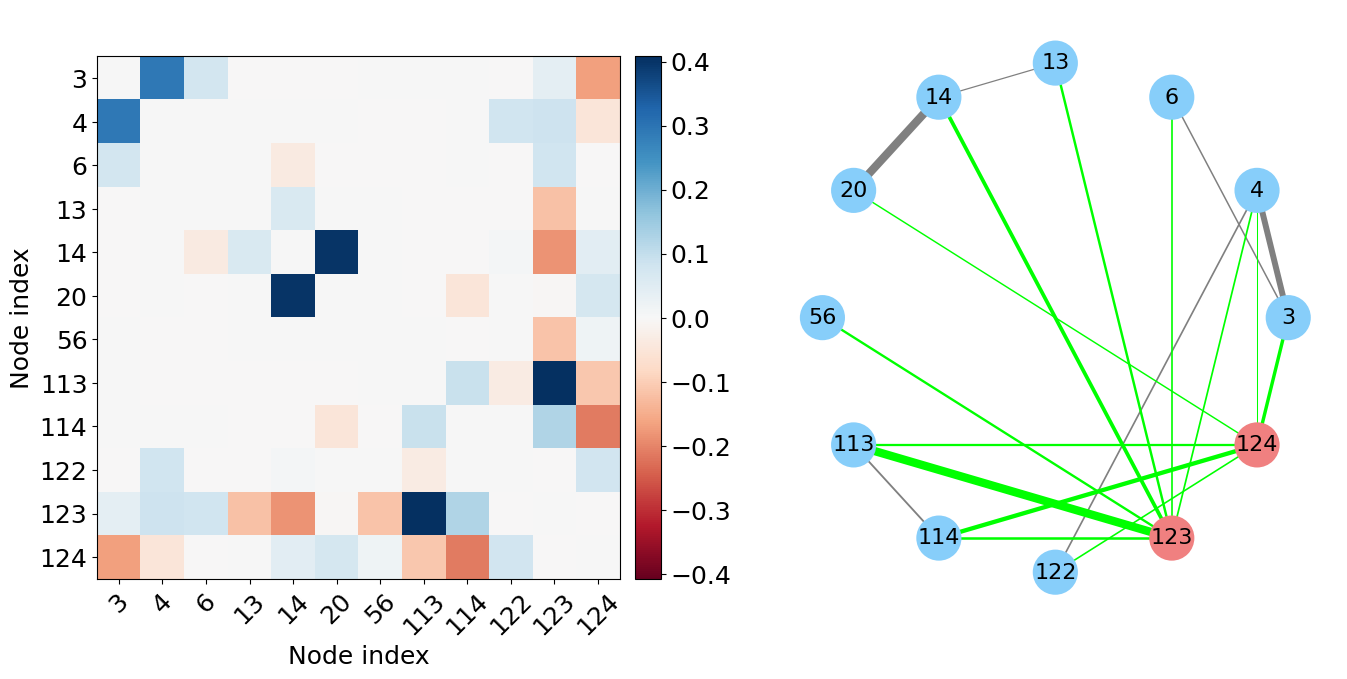

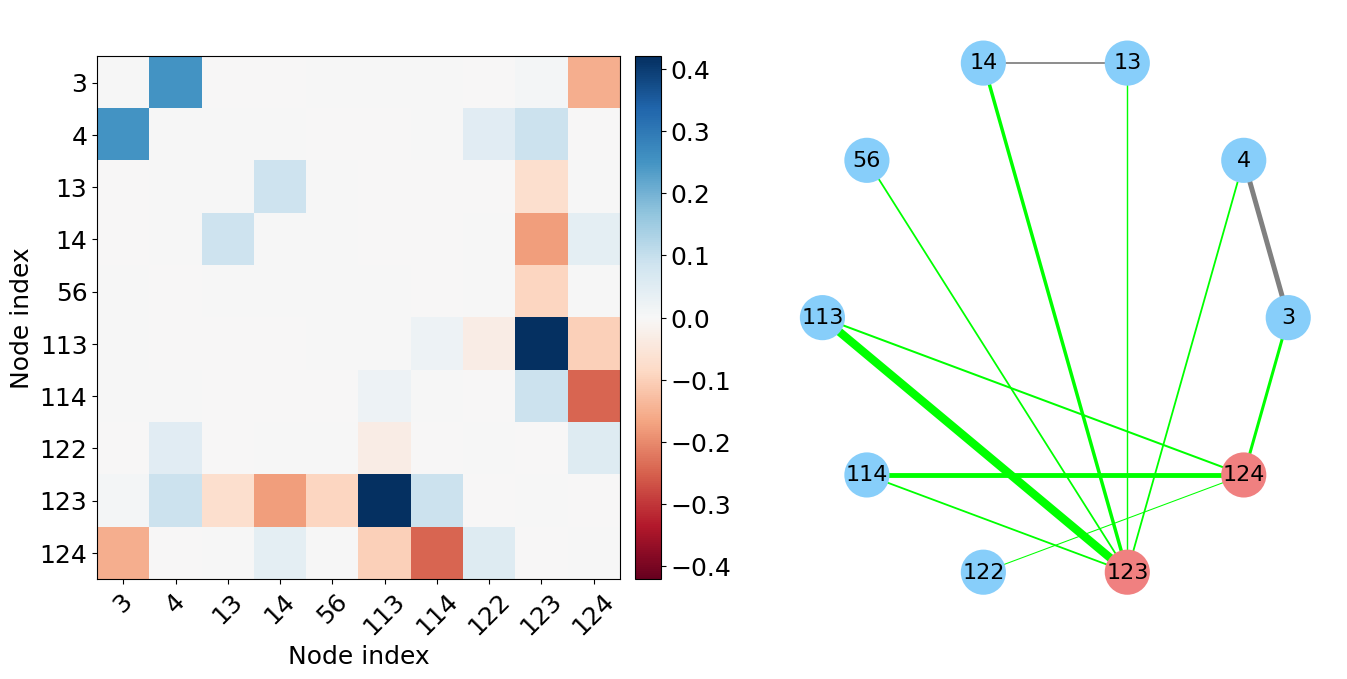

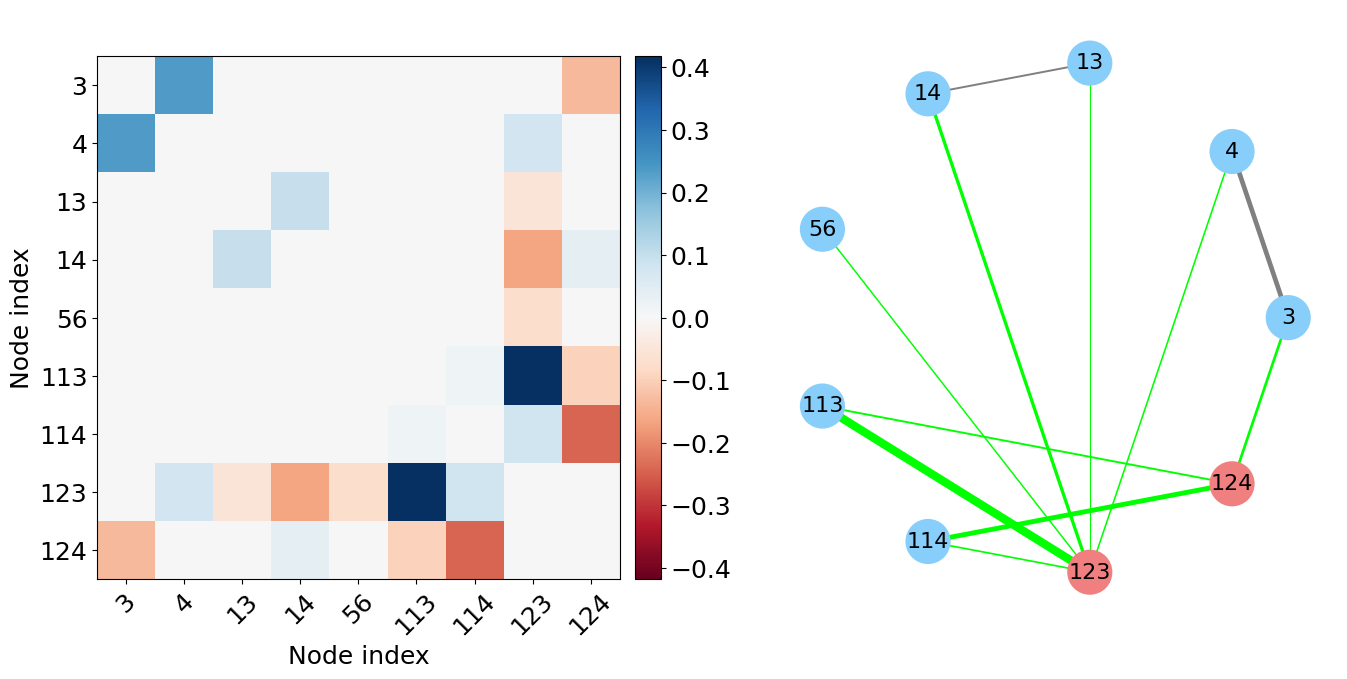

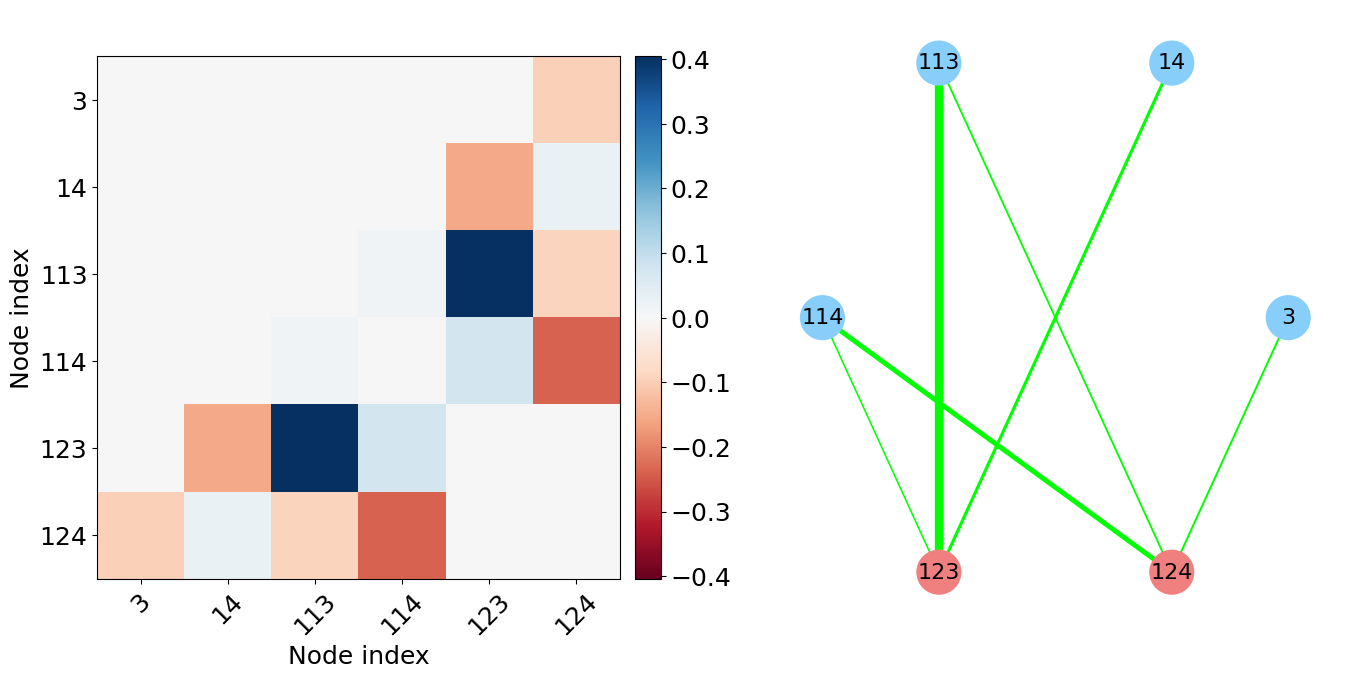

In [14]:
# Plot A
th = 0.05
for i, A_est in enumerate(A_undir_sem):
    mult = Mults[i] * lamb0
    file_name = f'{PREFIX}/sem_und_unc_{mult}'
    # utils.save_plot_graph(A_est, th, mult, max_width=4, file_name=file_name, save=SAVE)
    utils.save_plot_subgraph(A_est, th, mult, save=SAVE, max_width=6, file_name=file_name)
    utils.sort_edges_by_weight(A_est, th, output_file=file_name, abs_val=True, save=SAVE)

### Plot for different thresholds

Plotting grid for Lambda idx 0: 159.7800
	Individual plots saved in: ./results/sem_neg_unc/thresholds
Plotting grid for Lambda idx 3: 472.5900
	Individual plots saved in: ./results/sem_neg_unc/thresholds


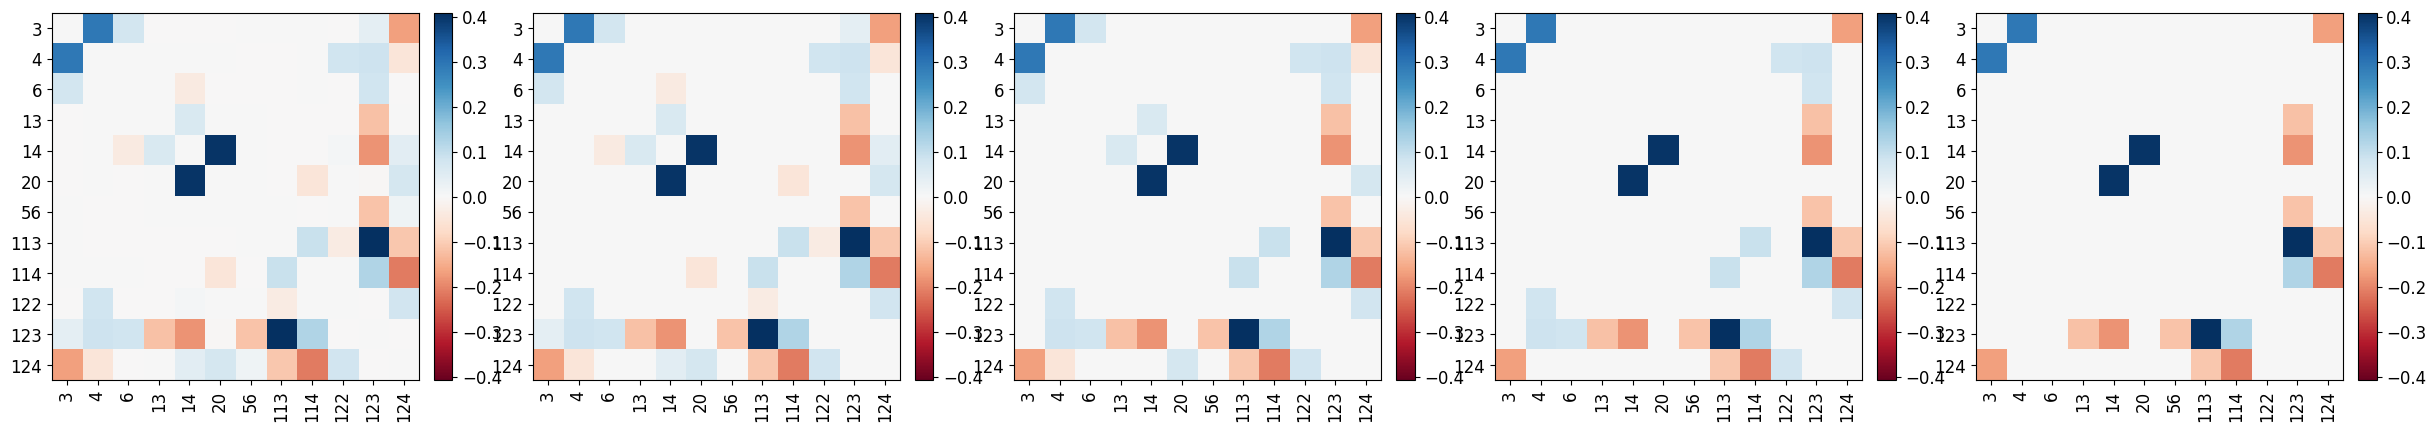

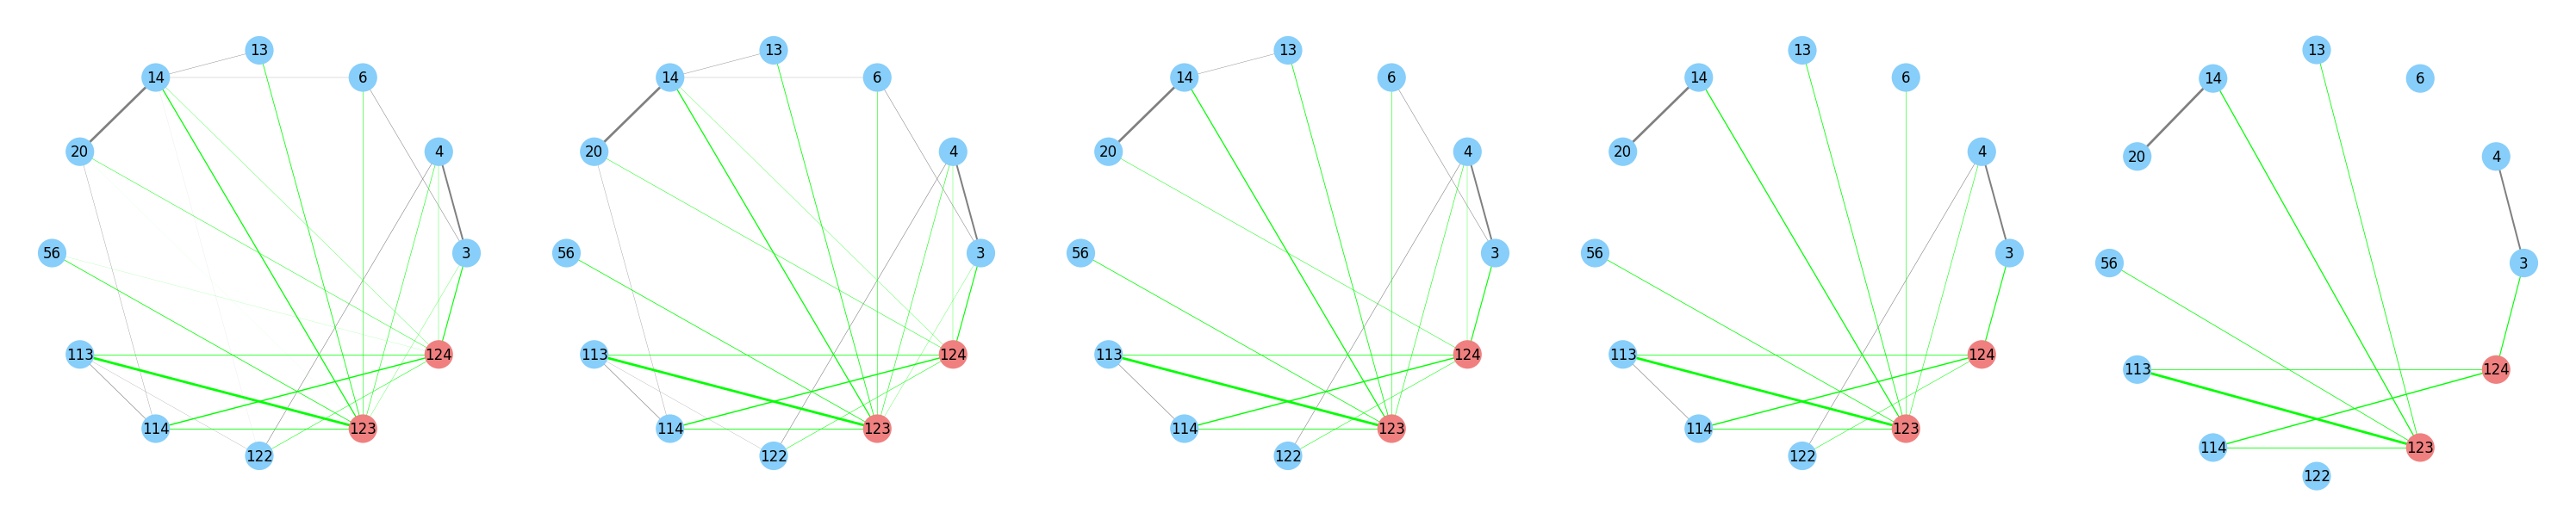

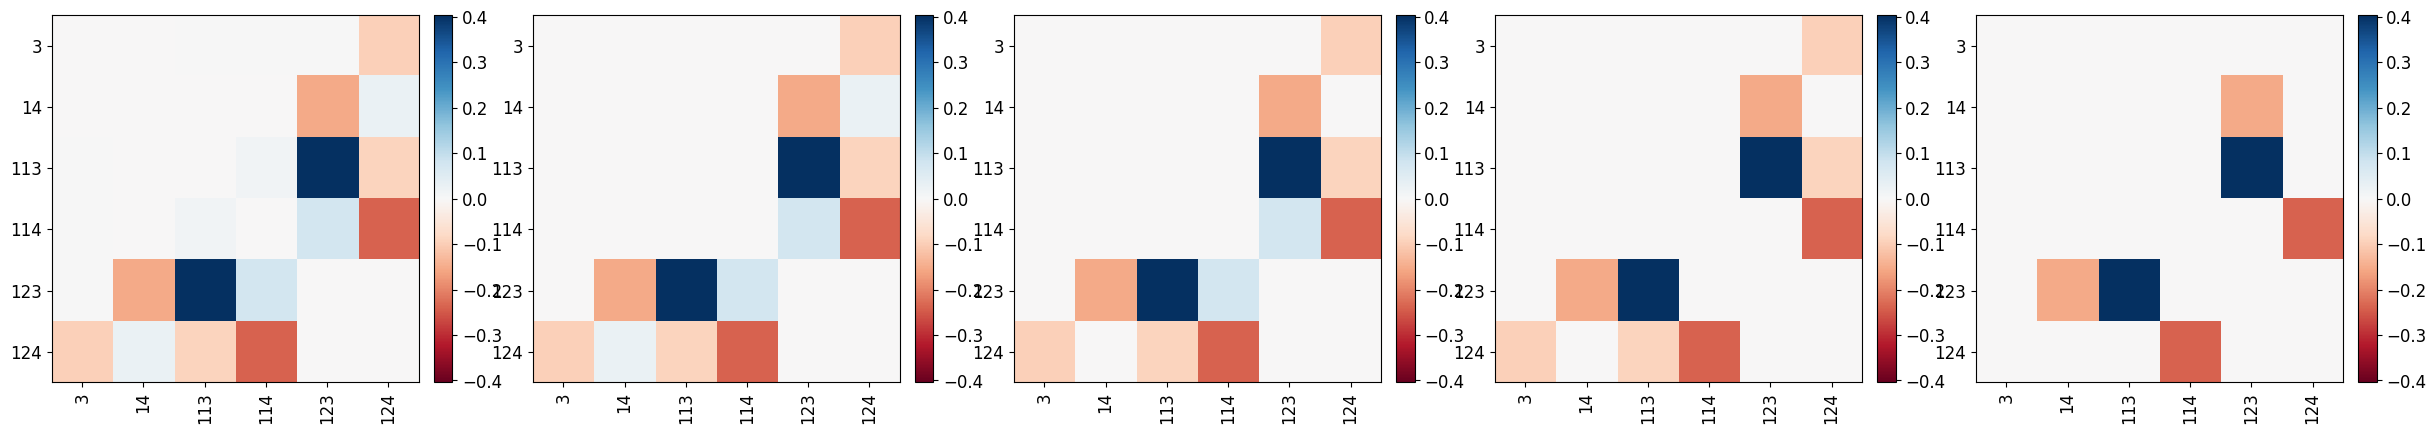

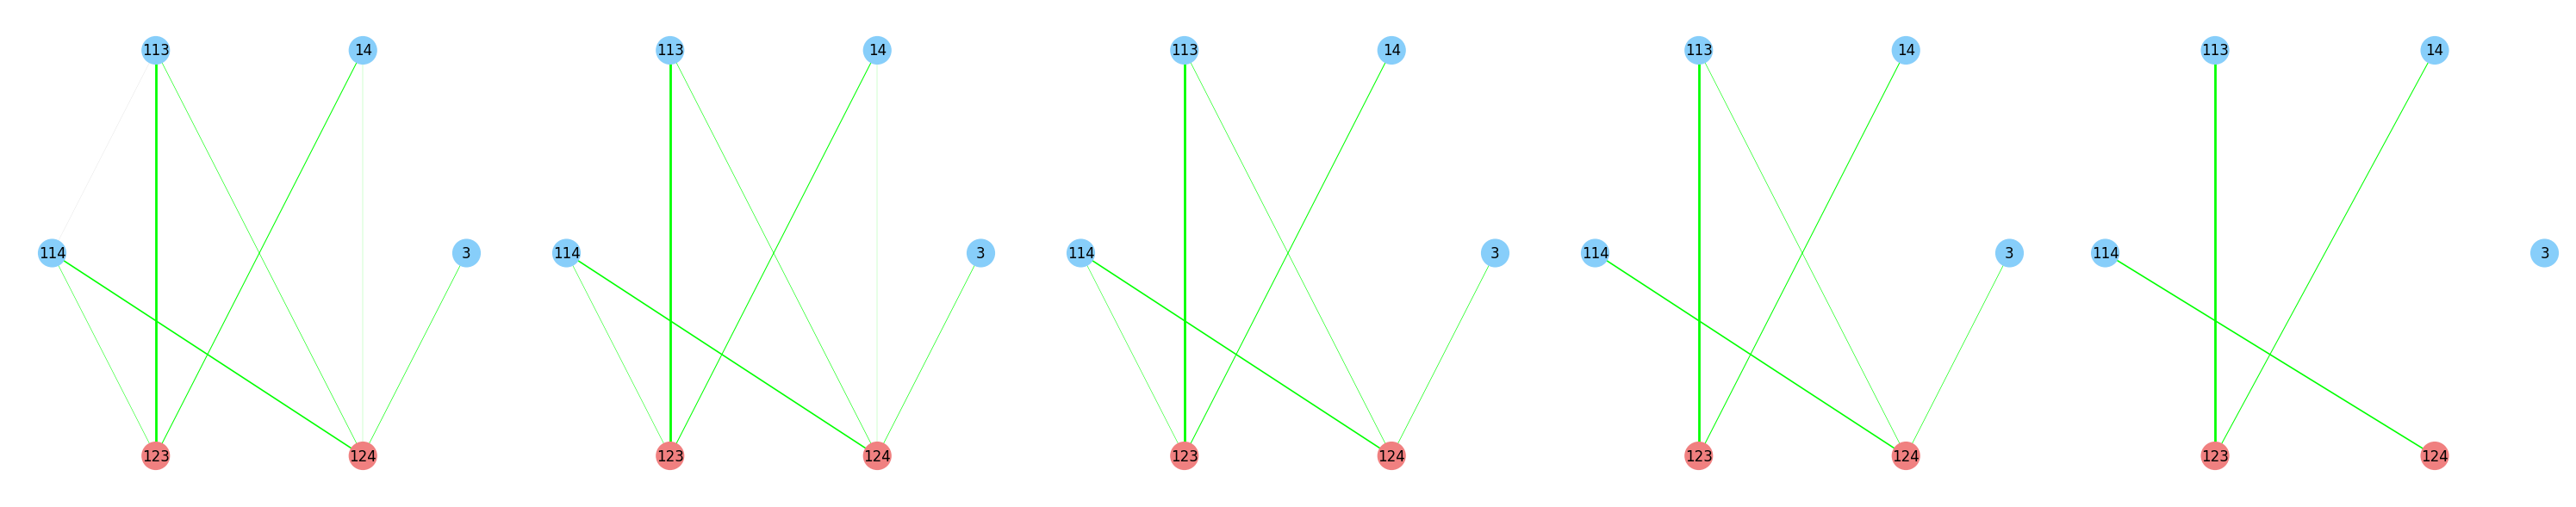

In [15]:
# Plot A - Grid for thresholds
fix_th = 0.05
thresholds = [0, 0.025, 0.05, 0.075, 0.1]

# skip_idx = [2,3]
skip_idx = [1,2]


# lambdas = Mults * lamb0

for i, A_est in enumerate(A_undir_sem):
    
    if i in skip_idx:
        continue
    
    lamb = Mults[i] * lamb0
    print(f'Plotting grid for Lambda idx {i}: {lamb:.4f}')
    
    utils.save_plot_subgraph_grid(A_est, thresholds, lamb, th_fixed_subgraph=fix_th, plot_graph=True,
                                  file_name=f'{PREFIX}/sem_und_unc_grid_fix_{lamb}', save=SAVE)
